In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from mlxtend.plotting import plot_decision_regions
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler


BEFORE USING MITO


In [38]:
# # Load dataset (Ensure correct file path)
# dataset = pd.read_csv("placement.csv")

# # Drop unnecessary column
# dataset.drop(columns=['Student_ID'], inplace=True, errors='ignore')

# # Rename columns for easier access
# dataset.rename(columns={'CGPA': 'cgpa', 'IQ': 'score', 'Placement': 'placement'}, inplace=True)

# # Display dataset details
# print(dataset.columns)
# print(dataset.head(5))


AFTER USING MITO 


In [41]:
# Load dataset (Ensure correct file path)
try:
    dataset = pd.read_csv("placement.csv")
except FileNotFoundError:
    print("File not found, please check the file path.")
    raise

# Drop unnecessary column
dataset.drop(columns=['Student_ID'], inplace=True, errors='ignore')

# Rename columns for easier access
dataset.rename(columns={'CGPA': 'cgpa', 'IQ': 'score', 'Placement': 'placement'}, inplace=True)

# Display enhanced dataset details
print("Dataset Columns:", dataset.columns.tolist())
print("\nFirst 5 Rows:")
print(dataset.head(5))
print("\nDataset Info:")
dataset.info()
print("\nDataset Description:")
print(dataset.describe())

Dataset Columns: ['Unnamed: 0', 'cgpa', 'iq', 'placement']

First 5 Rows:
   Unnamed: 0  cgpa     iq  placement
0           0   6.8  123.0          1
1           1   5.9  106.0          0
2           2   5.3  121.0          0
3           3   7.4  132.0          1
4           4   5.8  142.0          0

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB

Dataset Description:
       Unnamed: 0        cgpa          iq   placement
count  100.000000  100.000000  100.000000  100.000000
mean    49.500000    5.991000  123.580000    0.500000
std     29.011492    1.143634   39.944198    0.502519
min      0.000000    3.300000   37.000000    0

after mito 

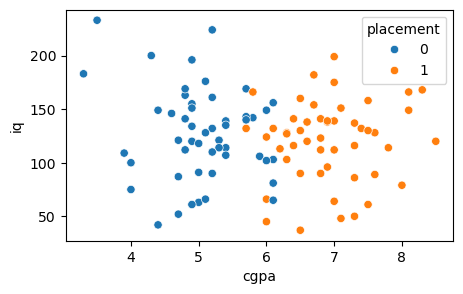

In [48]:
# Scatter plot of CGPA vs IQ, colored by Placement
plt.figure(figsize=(5,3))
sns.scatterplot(x="cgpa", y="iq", data=dataset, hue="placement")
plt.show()

In [52]:
# Selecting features and labels
x = dataset[['cgpa', 'iq']]
y = dataset['placement']

# Splitting dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=70)


In [54]:
# Standardizing the feature values
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [56]:
# Initialize and train the Perceptron model
pr = Perceptron(alpha=0.001, penalty='l2')
pr.fit(x_train, y_train)


Perceptron(alpha=0.001, penalty='l2')

In [58]:
# Calculate accuracy
train_acc = pr.score(x_train, y_train) * 100
test_acc = pr.score(x_test, y_test) * 100

# Print accuracy results
print(f"Train Accuracy: {train_acc:.2f}%, Test Accuracy: {test_acc:.2f}%")


Train Accuracy: 87.50%, Test Accuracy: 100.00%


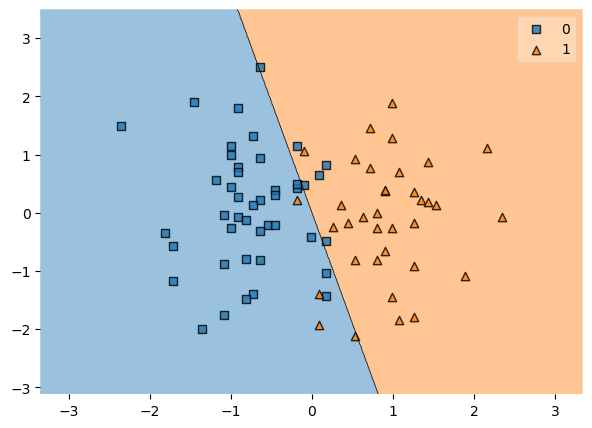

In [60]:
plt.figure(figsize=(7,5))
plot_decision_regions(x_train, y_train.to_numpy(), clf=pr)
plt.show()
